In [47]:
import roboticstoolbox as rtb
import numpy as np
from spatialmath import SE3

In [48]:
# Define Links
link1 = rtb.RevoluteDH(d=0.15185, a=0.0, alpha=np.pi/2)
link2 = rtb.RevoluteDH(d=0.0, a=-0.24355, alpha=0.0)
link3 = rtb.RevoluteDH(d=0.0, a=-0.2132, alpha=0.0)
link4 = rtb.RevoluteDH(d=0.13105, a=-0.0, alpha=np.pi/2)
link5 = rtb.RevoluteDH(d=0.08535, a=-0.0, alpha=-np.pi/2)
link6 = rtb.RevoluteDH(d=0.0921, a=-0.0, alpha=0.0)

# Create the Robot Object
ur3e = rtb.DHRobot([link1, link2, link3, link4, link5, link6], name="UR3e")

print(ur3e)

DHRobot: UR3e, 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │  0.1519 │       0 │  90.0° │
│  q2 │       0 │ -0.2435 │   0.0° │
│  q3 │       0 │ -0.2132 │   0.0° │
│  q4 │   0.131 │      -0 │  90.0° │
│  q5 │ 0.08535 │      -0 │ -90.0° │
│  q6 │  0.0921 │      -0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘



## Understanding the FK Output
The output you see above is a 4x4 Homogeneous Transformation Matrix.

   [ r11   r12   r13   tx ]
   [ r21   r22   r23   ty ]
   [ r31   r32   r33   tz ]
   [  0     0     0     1 ]

- Top-Left 3x3 (r values): Represents the Rotation (orientation) of the tool frame relative to the base.
- Right Column (tx, ty, tz): Represents the Translation (position X, Y, Z) of the tool frame relative to the base.

While matrices are great for math, they are hard for humans to read. We often convert this to XYZ (Position) and RPY (Roll-Pitch-Yaw / Orientation) for easier inspection.

In [49]:
tcp_pos = np.array([0.2, 0.2, 0.2])
tcp_rot = np.array([0, 0, 0])

T = SE3(tcp_pos) * SE3.RPY(tcp_rot)

sol = ur3e.ikine_LM(T)
print(sol.q)

[-2.83794577 -0.54661151  1.47379882  0.64360915 -1.57079593  1.26714942]


In [50]:
T_check = ur3e.fkine(sol.q)
print("\nCheck Pose:\n", T_check.t)


Check Pose:
 [0.2 0.2 0.2]


In [ ]:
from roboticstoolbox import ET

def get_joint_positions(joint_angles: np.ndarray) -> np.ndarray:
    robot = rtb.DHRobot([
        rtb.RevoluteDH(d=0.15185, a=0.0,      alpha=np.pi/2),
        rtb.RevoluteDH(d=0.0,     a=-0.24355, alpha=0.0),
        rtb.RevoluteDH(d=0.0,     a=-0.2132,  alpha=0.0),
        rtb.RevoluteDH(d=0.13105, a=0.0,      alpha=np.pi/2),
        rtb.RevoluteDH(d=0.08535, a=0.0,      alpha=-np.pi/2),
        rtb.RevoluteDH(d=0.0921,  a=0.0,      alpha=0.0)
    ], name="UR3e")

    # robot.fkine_all returns an SE3 object containing the transforms for every link
    transforms = robot.fkine_all(joint_angles)

    # Extract the translation (x, y, z) from each transformation matrix
    positions = np.array([T.t for T in transforms])

    # The fkine_all method returns frames 1 through N. 
    # To get a complete physical skeleton, we prepend the base frame (0, 0, 0).
    base_position = np.array([[0.0, 0.0, 0.0]])
    skeleton_nodes = np.vstack((base_position, positions))

    return skeleton_nodes

In [54]:
angles = np.array([0, -np.pi/2, 0, 0, 0, 0])
joint_coords = get_joint_positions(angles)
joint_coords


array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.51850000e-01],
       [-1.49131364e-17,  1.49131364e-17,  3.95400000e-01],
       [-2.79678713e-17,  2.79678713e-17,  6.08600000e-01],
       [-2.79678713e-17, -1.31050000e-01,  6.08600000e-01],
       [-8.53500000e-02, -1.31050000e-01,  6.08600000e-01],
       [-8.53500000e-02, -2.23150000e-01,  6.08600000e-01]])

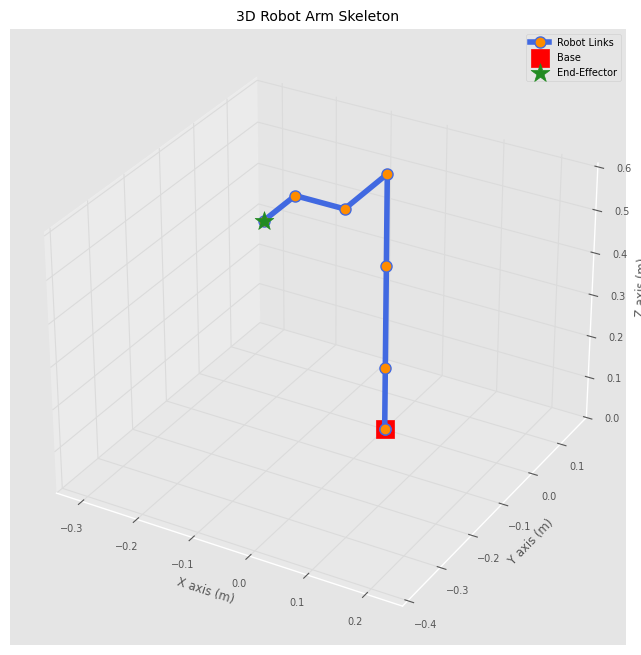

In [55]:
def plot_robot_skeleton(joint_coords: np.ndarray):
    """
    Plots a 3D skeleton of the robot arm using matplotlib.
    Assumes joint_coords is an (N, 3) numpy array.
    """
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Extract X, Y, and Z columns
    x = joint_coords[:, 0]
    y = joint_coords[:, 1]
    z = joint_coords[:, 2]

    # Plot the links (bones) and joints (nodes)
    ax.plot(x, y, z, color='royalblue', linewidth=4, marker='o', 
            markersize=8, markerfacecolor='darkorange', label='Robot Links')

    # Emphasize the Base (first point)
    ax.scatter(x[0], y[0], z[0], color='red', s=150, marker='s', label='Base')

    # Emphasize the End-Effector (last point)
    ax.scatter(x[-1], y[-1], z[-1], color='forestgreen', s=200, marker='*', label='End-Effector')

    # Formatting and labels
    ax.set_xlabel('X axis (m)')
    ax.set_ylabel('Y axis (m)')
    ax.set_zlabel('Z axis (m)')
    ax.set_title('3D Robot Arm Skeleton')
    ax.legend()

    # --- Ensure Equal Aspect Ratio ---
    # Matplotlib 3D axes auto-scale independently, which distorts robot proportions.
    # This block forces a cubic bounding box so the robot doesn't look stretched.
    max_range = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]).max() / 2.0
    
    mid_x = (x.max()+x.min()) * 0.5
    mid_y = (y.max()+y.min()) * 0.5
    mid_z = (z.max()+z.min()) * 0.5
    
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    # Display the plot
    plt.show()

# Example usage (assuming joint_coords is already generated):
plot_robot_skeleton(joint_coords)